In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def simular_cassino(n_jogadores=10, saldo_inicial=200):
  custo=20
  premios = [0 , 1, 1, 2, 20, 20,20,20,30,60]
  resultados= []
  for i in range(n_jogadores):
    jogadas = 0
    max_saldo= saldo_inicial
    saldo=saldo_inicial
    while saldo>=custo:
      ganho = np.random.choice(premios)
      saldo = saldo + ganho - custo
      jogadas+=1

      if saldo>max_saldo:
        max_saldo=saldo
    resultados.append({'jogador': i+1, "total_jogadas": jogadas,
                       "saldo_maximo": max_saldo})
  return pd.DataFrame(resultados)

size=100
md10=np.array(range(size))

for i in range(size):
  jogos = simular_cassino(100)
  md10[i]= jogos['total_jogadas'].mean()



print(f"Media10: {md10.mean()} Std10: {md10.std()}")

Media10: 71.53 Std10: 5.670017636656874


In [4]:
df = simular_cassino(1000)


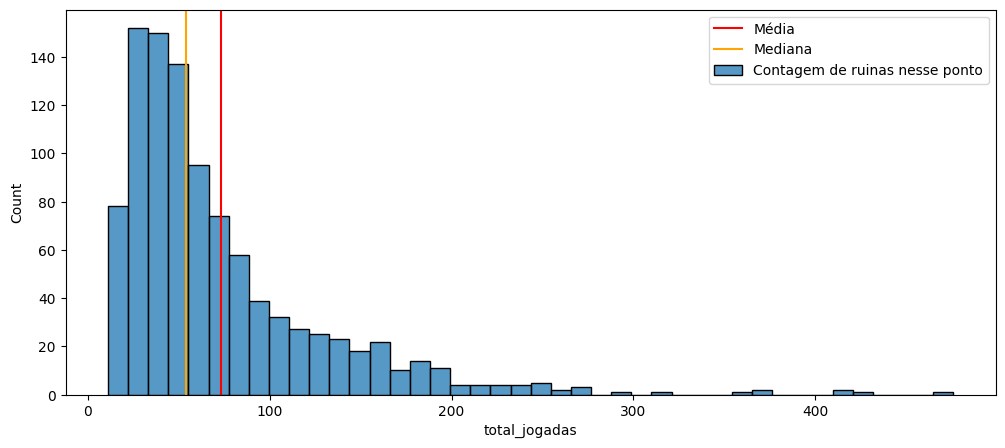

In [5]:
plt.figure(figsize=(12,5))
sns.histplot(df['total_jogadas'],label='Contagem de ruinas nesse ponto', )
plt.axvline(df['total_jogadas'].mean(), color='red', label='Média')
plt.axvline(df['total_jogadas'].median(), color='orange', label='Mediana')
plt.legend()

In [8]:
import plotly.express as px

fig = px.histogram(df, x="saldo_maximo", title="Distribuição de saldo máximo", opacity=0.7, color_discrete_sequence=['#000000'])
fig.show()

In [9]:
import random

In [ ]:
n_total = 1000

x = np.random.uniform(0, 1, n_total)
y = np.random.uniform(0, 1, n_total)

In [ ]:
px.scatter(x=x,y=y)

_________________________

In [16]:
n_total = 1000

x = np.random.uniform(0, 1, n_total)
y = np.random.uniform(0, 1, n_total)

inside = x**2 + y**2 <= 1
inside

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True, False,
        True,  True,  True, False, False,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True, False,  True, False, False,  True,  True,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True, False, False, False,  True,  True,
        True,  True,

In [18]:
np.sum(inside)/n_total*4

np.float64(3.132)

_______________
 

In [20]:
import yfinance as yf

In [21]:
ticker = "KO"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [23]:
data['retorno'] = data['Close'].pct_change()

In [26]:
data[['retorno', 'Close']]

Price,retorno,Close
Ticker,,KO
Date,,
2020-01-02,NaN,45.745098
2020-01-03,-0.005455,45.495544
2020-01-06,-0.000366,45.478893
2020-01-07,-0.007682,45.129520
2020-01-08,0.001843,45.212704
...,...,...
2023-12-22,0.005691,54.969810
2023-12-26,0.004115,55.196026


In [28]:
data.size

6036

In [29]:
retornos = data['retorno'].dropna().values

In [30]:
n_jogadores = 5000
n_dias = 252
investimento_inicial = 10000

matriz_retornos = np.random.choice(retornos, size=(n_jogadores, n_dias))

In [32]:
matriz_retornos[0][0]

np.float64(-0.00020633631797906116)

In [33]:
px.line(retornos)

In [34]:
px.line(matriz_retornos[0])

In [38]:
retornos_acumulados = np.cumprod(matriz_retornos + 1, axis=1)
retornos_acumulados

array([[0.99979366, 0.99034304, 0.98658513, ..., 0.95681076, 0.94975726,
        0.95244483],
       [0.98678989, 0.98078609, 0.91583183, ..., 1.03263906, 1.03949694,
        1.06487713],
       [0.98269442, 0.96971292, 0.96628881, ..., 1.59228329, 1.58666084,
        1.58799236],
       ...,
       [0.99880627, 0.99387387, 0.97721978, ..., 1.00471231, 1.02148584,
        1.04046017],
       [1.01135144, 1.00826205, 1.01554922, ..., 0.70124089, 0.69794608,
        0.71952168],
       [1.00338677, 1.01399736, 1.00758961, ..., 1.09470803, 1.0763643 ,
        1.07550782]], shape=(5000, 252))

In [39]:
px.line(retornos_acumulados[0])

In [40]:
ganhos_finais = retornos_acumulados[:,-1]

In [41]:
fig = px.histogram(x = ganhos_finais)
fig.show()